# Comparison of different capabilities of recognizing language in models

1. Training of Models on english literature, german literature, third one?

(https://huggingface.co/datasets/Dorian2B/french-literature-10K)

# Loading english literature

I started with the dataset manu/project_gutenberg which contains all the books on Gutenberg


In [18]:
import random
import re
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, GenerationConfig


The model gets tested on a number of books from the Gutenberg Project (https://www.gutenberg.org/)
Taken from the dataset manu/project_gutenberg

In [4]:
NUM_TARGET_BOOKS = 100

In [6]:
dataset = load_dataset("manu/project_gutenberg", split="en", streaming=True)

Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

This dataset contains an ID and the book. The book part usually has a part that says Title: ___

In [ ]:

def parse_metadata(text):
    title_match = re.search(r"Title:\s*(.*)", text, re.IGNORECASE)
    
    title = title_match.group(1).strip() if title_match else "Unknown Title"
    
    # Clean trailing carriage returns and potential unwanted tags if present
    title = re.sub(r'[\r\n]', '', title).strip()
    return title



Now the books are fetched and their titles and text saved

In [9]:

books = []
seen_titles = set()
iterator = iter(dataset)

while len(books) < NUM_TARGET_BOOKS:
    try:
        item = next(iterator)
        text = item["text"]
        title, author = parse_metadata(text)
        
        snippet_start = len(text) // 2
        snippet_end = len(text) // 2 + 1000
        snippet = text[snippet_start:snippet_end].strip()

        title_lower = title.lower()
        # Check that title was not added already (and a title exists)
        if (title != "Unknown Title" 
                and title_lower not in seen_titles):
            
            seen_titles.add(title_lower)
            books.append({
                "title": title,
                "text": snippet
            })
            
    except StopIteration:
        print("Error not all books fetched")
        break


Generating multiple choice answers. 

In [10]:
evaluation_set = []
all_titles = [b["title"] for b in books]

for book in books:
    # Generate 3 wrong options
    wrong_choices = [t for t in all_titles if t != book["title"]]
    choices = random.sample(wrong_choices, 3) + [book["title"]]
    random.shuffle(choices)  # Shuffle choices
    
    correct_answer = chr(65 + choices.index(book["title"]))  # A, B, C, or D
    
    evaluation_set.append({
        "snippet": book["text"],
        "choices": choices,
        "correct_letter": correct_answer,
        "correct_title": book["title"]
    })


# Qwen 7b-Model


In [11]:
model_name = "Qwen/Qwen2.5-7B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto" 
)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

In [ ]:
correct_predictions = 0
failed_parses = 0

for i, item in enumerate(evaluation_set):
    prompt_choices = "\n".join([f"{chr(65 + idx)}) {choice}" for idx, choice in enumerate(item["choices"])])
    
    system_prompt = (
        "Your task is to identify which book a provided text snippet belongs to. Respond ONLY with the single letter choice (A, B, C, or D) corresponding to the correct book title. Do not output anything else."
    )
    
    user_prompt = f"\n\"\"\"\n{item['snippet']}\n\"\"\"\n\nWhich book is this snippet from?\n{prompt_choices}\n\nAnswer (A/B/C/D):"
    
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
    text_input = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )
    
    model_inputs = tokenizer([text_input], return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=4,   
            temperature=0.1,
            do_sample=False     
        )

    # Decode only the newly generated tokens
    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]
    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0].strip().upper()
    
    # Extract letter from answer
    predicted_letter_match = re.search(r'[A-D]', response)
    if predicted_letter_match:
        predicted_letter = predicted_letter_match.group(0)
    else:
        predicted_letter = "Unknown"
        failed_parses += 1
    
    is_correct = (predicted_letter == item["correct_letter"])
    if is_correct:
        correct_predictions += 1

    # Track Accuracy Progress
    if (i + 1) % 10 == 0:
        current_acc = (correct_predictions / (i + 1)) * 100
        print(f"Evaluated {i+1}/{NUM_TARGET_BOOKS} | Running Accuracy: {current_acc:.1f}%")



[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Evaluated 5/100 | Running Accuracy: 0.0%
Evaluated 10/100 | Running Accuracy: 0.0%
Evaluated 15/100 | Running Accuracy: 6.7%
Evaluated 20/100 | Running Accuracy: 20.0%
Evaluated 25/100 | Running Accuracy: 16.0%
Evaluated 30/100 | Running Accuracy: 20.0%
Evaluated 35/100 | Running Accuracy: 22.9%
Evaluated 40/100 | Running Accuracy: 22.5%
Evaluated 45/100 | Running Accuracy: 20.0%
Evaluated 50/100 | Running Accuracy: 22.0%
Evaluated 55/100 | Running Accuracy: 20.0%
Evaluated 60/100 | Running Accuracy: 18.3%
Evaluated 65/100 | Running Accuracy: 18.5%
Evaluated 70/100 | Running Accuracy: 20.0%
Evaluated 75/100 | Running Accuracy: 21.3%
Evaluated 80/100 | Running Accuracy: 21.2%
Evaluated 85/100 | Running Accuracy: 21.2%
Evaluated 90/100 | Running Accuracy: 21.1%
Evaluated 95/100 | Running Accuracy: 24.2%
Evaluated 100/100 | Running Accuracy: 23.0%

                    FINAL RESULTS                    
Total Questions Evaluated: 100
Correct Answers:          23
Incorrect Answers:        77

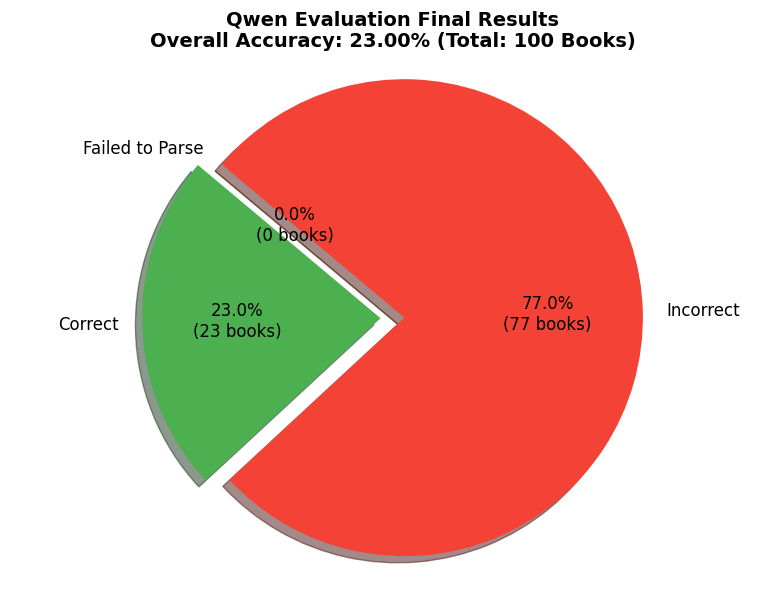

In [ ]:
import matplotlib.pyplot as plt

total_questions = len(evaluation_set)
incorrect_predictions = total_questions - correct_predictions - failed_parses

# Data to plot
labels = ['Correct', 'Incorrect', 'Failed to Parse']
sizes = [correct_predictions, incorrect_predictions, failed_parses]
colors = ['#4CAF50', "#E3311D", '#FF9800'] 
explode = (0.1, 0, 0)  

# Create the pie chart
plt.figure(figsize=(8, 6))
plt.pie(
    sizes, 
    explode=explode, 
    labels=labels, 
    colors=colors,
    autopct=lambda p: '{:.1f}%\n({:.0f} books)'.format(p, p * total_questions / 100),
    shadow=True, 
    startangle=140,
    textprops={'fontsize': 12}
)

# Set title with overall model accuracy
accuracy = (correct_predictions / total_questions) * 100
plt.title(f"Qwen Evaluation Final Results\nOverall Accuracy: {accuracy:.2f}% (Total: {total_questions} Books)", fontsize=14, fontweight='bold')

# Ensure the pie chart is drawn as a circle
plt.axis('equal')  

# Show the plot window
plt.tight_layout()
plt.show()
